## **Partie 1 : Compréhension des données**

### **Importation des bibliothèques**

In [3]:
import json  #lire les fichiers .jsonl
from pathlib import Path #gérer les chemins de manière portable

import pandas as pd #manipuler les données
import matplotlib.pyplot as plt #réaliser quelques graphiques simples

### **Définition des chemins**

In [20]:
DATA_DIR = Path("/mnt/c/Users/KSOMS/Favorites/TTA-assan-cyriac-abonouan/fact-checker/data/fever") #On va éviter d'écrire les chemins en dur partout dans le notebook

TRAIN_FILE = DATA_DIR / "train.jsonl"
DEV_FILE = DATA_DIR / "shared_task_dev.jsonl"
TEST_FILE = DATA_DIR / "shared_task_test.jsonl"

### **LECTURE DES FICHIERS**

In [21]:
def load_jsonl(path):
    data = []

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            data.append(json.loads(line))

    return data

### **Chargement des données**

In [22]:
train_data = load_jsonl(TRAIN_FILE)
dev_data = load_jsonl(DEV_FILE)
test_data = load_jsonl(TEST_FILE)

print(f"Train : {len(train_data):,}")
print(f"Dev   : {len(dev_data):,}")
print(f"Test  : {len(test_data):,}")

Train : 145,449
Dev   : 19,998
Test  : 19,998


* Le jeu d'entraînement est suffisamment grand pour entraîner ou évaluer plusieurs composants.
* Le jeu de validation (Dev) servira à tester notre pipeline pendant le développement.
* Le jeu de test sera réservé à l'évaluation finale. Nous ne l'utiliserons pas pour prendre des décisions de conception afin d'éviter tout biais.

In [25]:
pprint.pp(train_data[0], sort_dicts=False)

{'id': 75397,
 'verifiable': 'VERIFIABLE',
 'label': 'SUPPORTS',
 'claim': 'Nikolaj Coster-Waldau worked with the Fox Broadcasting Company.',
 'evidence': [[[92206, 104971, 'Nikolaj_Coster-Waldau', 7],
               [92206, 104971, 'Fox_Broadcasting_Company', 0]]]}


* **id** : identifiant unique du claim
* **verifiable** : NOT VERIFIABLE / VERIFIABLE (Il y certaines requête qui peuvent être vérifier avec wikipedia tandis que d'autres non). Dans le cas où c'est VERIFIABLE, Wikipédia contient suffisamment d'informations pour décider si cette affirmation est vraie ou fausse
* **label** : SUPPORTS / REFUTES / NOT ENOUGH INFO 
    * SUPPORTS → l'affirmation est soutenue par les preuves.
    * REFUTES → les preuves contredisent l'affirmation.
    * NOT ENOUGH INFO → les preuves disponibles ne permettent pas de conclure.
* **claim** : C'est l'entrée de notre pippeline (requête ou affirmation)
* **evidence** : Ceux sont les preuvent dont nous disposons pour affirmer ou infirmer un claim, nous avons d'abord le lien wikipedia (''Nikolaj_Coster-Waldau' ou encore 'Fox_Broadcasting_Company' ) et la phrase en question (7, 0). Les deux premiers nombres sont des identifiants internes utilisés par FEVER.

Pour notre pipeline, nous n'en aurons pas besoin. Nous utiliserons plutôt :
* le titre de la page ;
* le numéro de phrase ;
* le texte de la phrase.

Car les preuves peuvent être réparties dans différents articles, voire dans plusieurs phrases d'un même article. Un index de passages sera donc beaucoup plus efficace qu'un index d'articles entiers.

## **Partie 2 : Analyse statistique de FEVER**

### **Transformation des données en DataFrame**

In [26]:
df_train = pd.DataFrame(train_data)

df_train.head()

,id,verifiable,label,claim,evidence
0,75397,VERIFIABLE,SUPPORTS,Nikolaj Coster-Waldau worked with the Fox Broa...,"[[[92206, 104971, Nikolaj_Coster-Waldau, 7], [..."
1,150448,VERIFIABLE,SUPPORTS,Roman Atwood is a content creator.,"[[[174271, 187498, Roman_Atwood, 1]], [[174271..."
2,214861,VERIFIABLE,SUPPORTS,"History of art includes architecture, dance, s...","[[[255136, 254645, History_of_art, 2]]]"
3,156709,VERIFIABLE,REFUTES,Adrienne Bailon is an accountant.,"[[[180804, 193183, Adrienne_Bailon, 0]]]"
4,83235,NOT VERIFIABLE,NOT ENOUGH INFO,System of a Down briefly disbanded in limbo.,"[[[100277, None, None, None]]]"


Un DataFrame facilite les analyses, les statistiques et les visualisations.

### **Informations générales**

In [27]:
print(f"Nombre de claims : {len(df_train):,}\n")

df_train.info()

Nombre de claims : 145,449

<class 'pandas.DataFrame'>
RangeIndex: 145449 entries, 0 to 145448
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   id          145449 non-null  int64 
 1   verifiable  145449 non-null  str   
 2   label       145449 non-null  str   
 3   claim       145449 non-null  str   
 4   evidence    145449 non-null  object
dtypes: int64(1), object(1), str(3)
memory usage: 5.5+ MB


Nous avons 5 colonnes (id de type entier, verifiable, label et claim de type chaine de charactère, et evidence de type objet) ainsi que 145449 entrées
On observe aussi qu'il n'y pas de valeur manquante

In [28]:
df_train.columns.tolist()

['id', 'verifiable', 'label', 'claim', 'evidence']

### **Distribution des `labels`**

In [29]:
label_counts = df_train["label"].value_counts()

print(label_counts)

label
SUPPORTS           80035
NOT ENOUGH INFO    35639
REFUTES            29775
Name: count, dtype: int64


**Le dataset n'est pas parfaitement équilibré**  

On observe que :

* SUPPORTS représente plus de la moitié du dataset.
* REFUTES est la classe la moins représentée.
* NOT ENOUGH INFO (NEI) constitue environ un quart des exemples.

**Ce que cela implique**

Si nous entraînions un modèle directement sur ces données, il pourrait avoir tendance à prédire plus souvent SUPPORTS.

Cependant, dans notre projet, nous ne prévoyons pas d'entraîner un classificateur directement sur FEVER. Notre pipeline reposera sur :

Claim -> Retrieval -> Evidence -> NLI -> Verdict

Le modèle NLI sera déjà pré-entraîné. Nous utiliserons donc FEVER principalement pour :

* évaluer le pipeline ;
* mesurer les performances du retrieval ;
* comparer les verdicts générés avec les labels officiels.

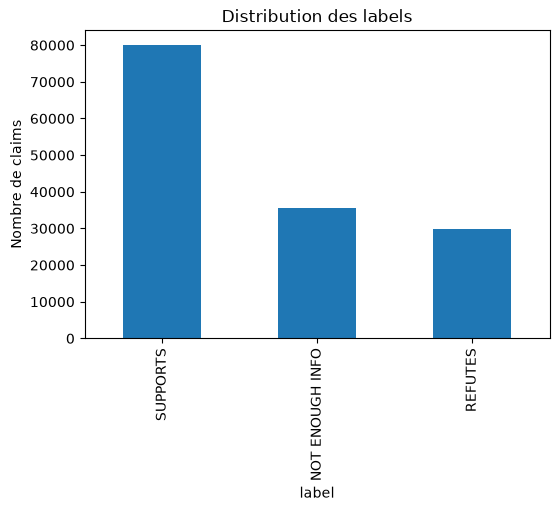

In [30]:
label_counts.plot(
    kind="bar",
    figsize=(6,4),
    title="Distribution des labels"
)

plt.ylabel("Nombre de claims")
plt.show()

Le graphique ci-dessus montre comment sont réparties les labels.
La majorité des affirmations ont été confirmé avec des preuves

### **Longueur des `claims`**

In [33]:
df_train["claim_length"] = df_train["claim"].apply(
    lambda x: len(x.split())
)

df_train["claim_length"].describe()

count    145449.000000
mean          8.101389
std           3.205078
min           2.000000
25%           6.000000
50%           8.000000
75%          10.000000
max          65.000000
Name: claim_length, dtype: float64

La première chose qui saute aux yeux est que les claims sont très courts.
* Moyenne : 8 mots
* Médiane : 8 mots
* 75 % des claims font 10 mots ou moins

Autrement dit, FEVER est essentiellement composé de phrases courtes et factuelles.

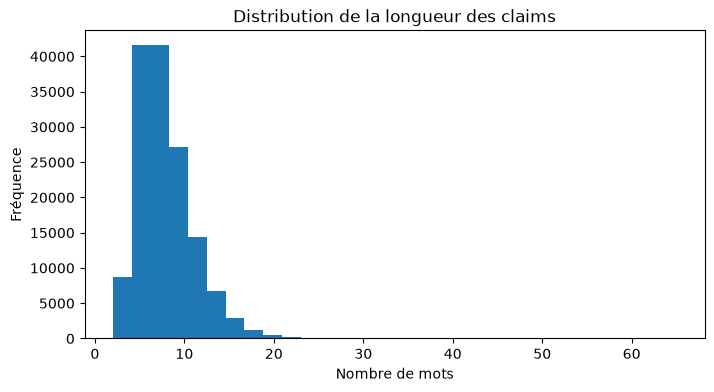

In [34]:
plt.figure(figsize=(8,4))

plt.hist(
    df_train["claim_length"],
    bins=30
)

plt.title("Distribution de la longueur des claims")
plt.xlabel("Nombre de mots")
plt.ylabel("Fréquence")

plt.show()

### **Impact sur notre pipeline**

Cette statistique influence directement plusieurs composants.

#### **1. Retrieval**

Comme les requêtes sont très courtes, la recherche basée uniquement sur des mots-clés (BM25) peut manquer des documents pertinents lorsque le vocabulaire diffère.

C'est une des raisons pour lesquelles nous avons choisi une recherche hybride :

* BM25 pour les correspondances lexicales.
* Embeddings pour les correspondances sémantiques.

Les deux approches sont complémentaires.

#### **2. Embeddings**

Avec des requêtes de seulement quelques mots, il nous faut un modèle d'embeddings performant sur les textes courts. C'est l'une des raisons pour lesquelles nous avions retenu BAAI/bge-base-en-v1.5.

#### **3. Chunking**

Les claims étant courts, le contexte viendra principalement des passages Wikipédia. Cela confirme notre choix de chunks d'environ 200 mots avec un chevauchement.

### **Distribution de `verifiable`**

In [31]:
df_train["verifiable"].value_counts()

verifiable
VERIFIABLE        109810
NOT VERIFIABLE     35639
Name: count, dtype: int64

Dans notre ensemble de données, 109810 affirmations disposait de sources vérifiables.
De plus on constate que le nombre de données NOT VERIFIABLE et NOT ENOUGH INFO sont identiques. Autrement dit :
* si verifiable = VERIFIABLE, alors le label sera soit SUPPORTS, soit REFUTES.
* si verifiable = NOT VERIFIABLE, alors le label sera toujours NOT ENOUGH INFO.

On peut donc conclure que lorsqu'on ne peut pas vérifier une information avec wikipedia, il reçoit NOT ENOUGH INFO, dans le cas contraire, soit on ettaye (SUPPORTS) ou on refute (REFUTES)

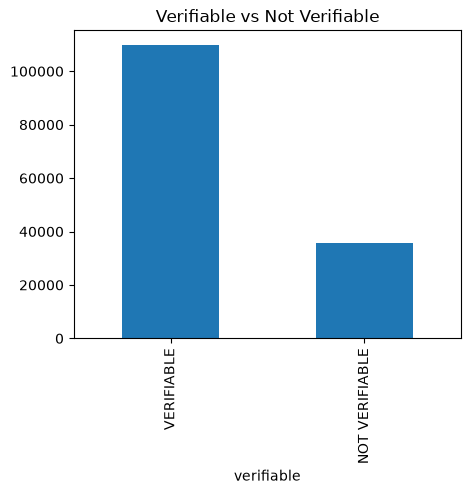

In [32]:
df_train["verifiable"].value_counts().plot(
    kind="bar",
    figsize=(5,4),
    title="Verifiable vs Not Verifiable"
)

plt.show()

On observe qu'une très grande partie des affirmations disposaient de sources source sûr et existante

### **Analyse de la variable `evidence`**

In [36]:
from collections import Counter

evidence_set_sizes = []
sentence_counts = []
document_counts = []

for row in train_data:
    # Les exemples NOT ENOUGH INFO n'ont pas de preuves exploitables
    if row["label"] == "NOT ENOUGH INFO":
        continue

    evidence_sets = row["evidence"]

    # Nombre d'ensembles de preuves
    evidence_set_sizes.append(len(evidence_sets))

    for evidence_set in evidence_sets:
        # Nombre de phrases dans cet ensemble
        sentence_counts.append(len(evidence_set))

        # Nombre de documents différents
        docs = {e[2] for e in evidence_set}
        document_counts.append(len(docs))

In [38]:
print("Nombre moyen d'ensembles de preuves :", round(sum(evidence_set_sizes) / len(evidence_set_sizes), 2))
print("Nombre moyen de phrases par preuve :", round(sum(sentence_counts) / len(sentence_counts), 2))
print("Nombre moyen de documents par preuve :", round(sum(document_counts) / len(document_counts), 2))

Nombre moyen d'ensembles de preuves : 2.02
Nombre moyen de phrases par preuve : 1.19
Nombre moyen de documents par preuve : 1.16


On observe que chaque claim est fourni avec au moins 2 preuves donc deux façons d'être prouver. Cela signifie que FEVER n'impose pas une preuve unique. Il peut exister plusieurs chemins pour démontrer la même affirmation.  
En conséquence, notre pipeline ne doit pas chercher une seule preuve, il doit chercher plusieurs candidats, puis laisser le reranker et le vérificateur choisir les meilleurs.
C'est exactement pour cela que nous avions prévu cette architecture:  
Hybrid Retrieval -> Top 100 passages -> Cross Encoder -> Top 10 passages  
Cette décision est maintenant justifiée par les données.

On a aussi dans la plus part des cas une phrase par preuve, ce qui signifie que généralement une phrase suffit pour prendre une décision (affirmer ou infirmer). Les cas où il faut deux ou trois phrases existent, mais ils sont minoritaires.  
En conséquence, si une preuve utilise une phrase, ou deux phrases voisines, elles seront probablement lié.

On remarque aussi que la plupart des preuves proviennent d'un seul document Wikipédia. Cependant certains necessite deux ou trois documents. Notre pipeline doit pouvoir récupérer :
* plusieurs documents ;
* plusieurs passages ;
* puis les fusionner.